# Lakeshore Log Plotter
This notebook can be used to retriece and plot the information contained in a Lakeshore log file. It also loads the frdige logs to compate temperatures as measured directly with the iMACRT system.

The logs need to be locally present on the machine running this notebook. The following commands can be used to retrieve the log files over the NEXUS LAN.

`$ rsync -avu nexusgateway:/mnt/NexusData/Bridge/Temperature_20220419.txt ./`

`$ scp /home/LogData/LakeshoreData/Temperature_20240726.txt nexus-admin@192.168.0.42:/data/SlowDataLogCopies/`

In [1]:
import os
import time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

Define the log file of interest. For now this script only loads one day at a time

In [2]:
date  = "20240727" # "20240726"

fname = "Temperature_" + date + ".txt"
fpath = "/data/SlowDataLogCopies"#"/home/nexus-admin/Downloads"
path  = os.path.join(fpath,fname)

## Define Utility Methods

### String to timestamp converter
Takes a date/time string in the log file format and returns a unix timestamp. This is used to add a column to the dataframe containing the log file info.

In [3]:
def timeConvert(tstr):
    return time.mktime(datetime.datetime.strptime(tstr.strip(), "%Y-%m-%d %H:%M:%S.%f").timetuple())

### Lakeshore log file parser
Given a path to a local copy of the Lakeshore log file, this method constructs and returns a dataframe containing all the information in the log.

In [4]:
def parse_lakeshore_log_to_df(lakeshore_log_path, verbose=False):
    ## Extract the header column names
    col_names = None
    with open(path,"r") as f:
        col_names = f.readline().split()
    if verbose: print(col_names)

    ## Create an empty dataframe with column names
    df = pd.DataFrame(columns=col_names)

    with open(path,"r") as f:
        ## Get all the lines in the files
        lines = f.readlines()

        ## Count the number of lines in the file 
        nline = len(lines)

        ## Loop over all rows in file, skipping the first
        for i in 1+np.arange(nline-1):

            ## Parse the line
            line = None
            line = np.array(lines[i].split("\t"))
            l1t  = np.append(line[0:4] , line[4].split())
            line = np.append( l1t, line[5:])
            line[3] = line[3].replace("K","")

            ## Make sure the line has the right number of entries
            if len(line) != len(col_names):
                line = np.append(line, np.empty((len(col_names)-len(line),1), dtype=str))

            ## Add row to end of DataFrame
            df.loc[len(df.index)] = line

    ## Add a converted timestamp column to the dataframe
    df["Tstamp"] = df["Time"].apply(timeConvert)
    
    return df

### Channel data plotter
For a provided log file dataframe object, produce a plot object for a specified channel. If a pyplot `fig` object is passed with the keywork argument `fig_obj` this method adds the requested channel's data to the existing figure. If not, it creates and returns a new figure.

In [5]:
def plotChannel(log_df, chan, fig_obj=None, label=None):
    
    ## Ensure we're looking at strings only
    if not (type(chan)==type("s")):
        chan = str(chan)
        
    ## Get the dataframe entries for this channel
    chan_df = df[ df["Channel"] == chan ]
    
    ## Get the data to plot
    t_vals = chan_df["Tstamp"].to_numpy().astype(type(1.1))      ## Epoch seconds
    T_vals = chan_df["Temperature"].to_numpy()                   ## Kelvin
    
    ## Clean and recast the data of interest
    T_vals[ T_vals == 'Out of Range' ] = np.nan
    T_vals[ T_vals == 'N/A' ] = np.nan
    T_vals    = 1000.0 * T_vals.astype(type(1.1))                ## milliKelvin
    t_vals_dt = np.vectorize(datetime.datetime.fromtimestamp)(t_vals-5*3600)
    
    ## Create the plot
    if fig_obj is None:
        fig = plt.figure()
    ax0 = fig_obj.gca()
    ax0.set_xlabel("Time")
    ax0.set_ylabel("Temperature [mK]")
    
    ## Draw the line
    ax0.plot(t_vals_dt,T_vals,label=label)
    
    ## Change the time format
    ax0.xaxis.set_major_formatter( DateFormatter('%H:%M:%S') )
    for tick in ax0.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('right')
        tick.set_rotation(30)

    return fig_obj, ax0

## Load the Data
Now actually load the data from the specified date into a dataframe

In [6]:
df = parse_lakeshore_log_to_df(path)
## Show the user the data
df

,Channel,Measurement,Resistance,Temperature,Res,Range,Excitation,Time,ControlSetup,ControlChannel,CurveName,HeaterRange,PID_P,PID_I,PID_D,SetupUnit,SetPoint,HeatResistance,HeaterPower,Tstamp
0,5,DC Tower Therm Soudan#12,2660.25 Ohms,0.058381,6.32,kOhms,6.32 uV,2024-07-27 05:00:01.245\n,,,,,,,,,,,,1.722074e+09
1,11,SQUID Board Therm Soudan#11,2054.68 Ohms,0.181116,6.32,kOhms,20.0 uV,2024-07-27 05:00:09.920\n,,,,,,,,,,,,1.722074e+09
2,13,PT Fridge Touch Sensor Resistor(50 kOhm),50731 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-27 05:00:18.580\n,,,,,,,,,,,,1.722074e+09
3,4,RF Payload Therm TT2101,15597 Ohms,0.057790,20.0,kOhms,6.32 uV,2024-07-27 05:00:27.420\n,,,,,,,,,,,,1.722074e+09
4,5,DC Tower Therm Soudan#12,2677.23 Ohms,0.056619,6.32,kOhms,6.32 uV,2024-07-27 05:00:36.111\n,,,,,,,,,,,,1.722074e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,5,DC Tower Therm Soudan#12,2484.84 Ohms,0.080474,6.32,kOhms,6.32 uV,2024-07-27 16:01:17.608\n,,,,,,,,,,,,1.722114e+09
1426,11,SQUID Board Therm Soudan#11,2047.29 Ohms,1.018941,6.32,kOhms,20.0 uV,2024-07-27 16:01:26.310\n,,,,,,,,,,,,1.722114e+09
1427,13,PT Fridge Touch Sensor Resistor(50 kOhm),50754 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-27 16:01:34.969\n,,,,,,,,,,,,1.722114e+09
1428,4,RF Payload Therm TT2101,13054.3 Ohms,0.074019,20.0,kOhms,6.32 uV,2024-07-27 16:01:43.759\n,,,,,,,,,,,,1.722114e+09


In [7]:
## Show the user the unique channels that are logged in this file
chans = set(df["Channel"])
print("Channels available in this log file:", chans)

Channels available in this log file: {'4', '11', '5', '13'}


(19931.0, 19931.459381364304)

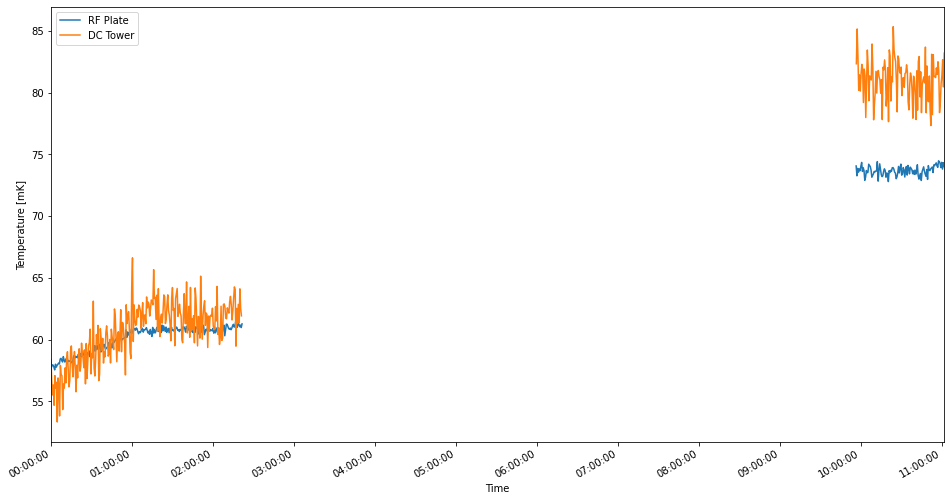

In [8]:
# %matplotlib notebook
fig = plt.figure(figsize=(16,8))
plotChannel(df, 4,fig_obj=fig,label="RF Plate")
plotChannel(df, 5,fig_obj=fig,label="DC Tower")
plt.legend()

xlim = plt.gca().get_xlim()
fig.gca().set_xlim([datetime.datetime(int(date[0:4]),int(date[4:6]),int(date[6:8]),0,0,0) , datetime.datetime.now()])

## Load the iMACRT Temperatures

In [9]:
import sys
sys.path.append('../')
import NEXUSFunctions as nf

import matplotlib.dates as mdates
from   pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [10]:
seriesstr = "-".join([date[0:4],date[4:6],date[6:8]])
series    = nf.create_date_range(seriesstr,1)
offset_0  = datetime.timedelta(days=0, hours=0, minutes=0)
offset_ls = datetime.timedelta(days=0, hours=-5, minutes=0)

The starting date is: 
2024-07-27 00:00:00


In [11]:
res_mc    = nf.read_MACRT_data(series, offset_0)

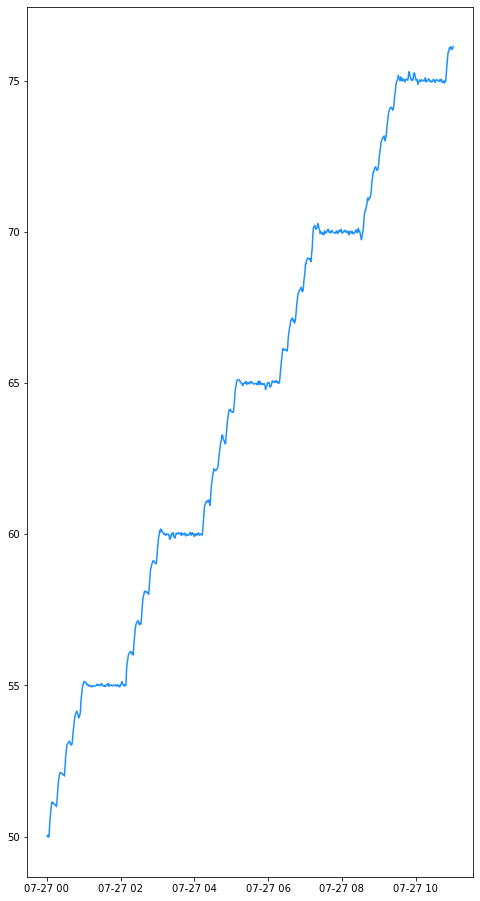

In [12]:
## Plot the MACRT data
plt.figure(figsize=(8,16))
plt.plot(res_mc['ctime'], res_mc['MIXING CHAMB_Conv']*1e3, label='MACRT - MC', color='dodgerblue', zorder=10)

## Load the PLC Temperatures

In [13]:
seriesstr  = "".join([date[2:4],date[4:6],date[6:8]])
series_plc = nf.create_date_range(seriesstr, 1, fmt="%y%m%d")
offset_plc = datetime.timedelta(days=0, hours=0, minutes=0)
data_plc   = nf.read_plclog_data(series_plc, offset_plc)

The starting date is: 
2024-07-27 00:00:00


In [14]:
def get_datetime(obj):
    return obj.to_pydatetime()

data_plc['datetime'] = data_plc['ctime'].apply(get_datetime)
res_mc['datetime'] = res_mc['ctime'].apply(get_datetime)

<IPython.core.display.Javascript object>


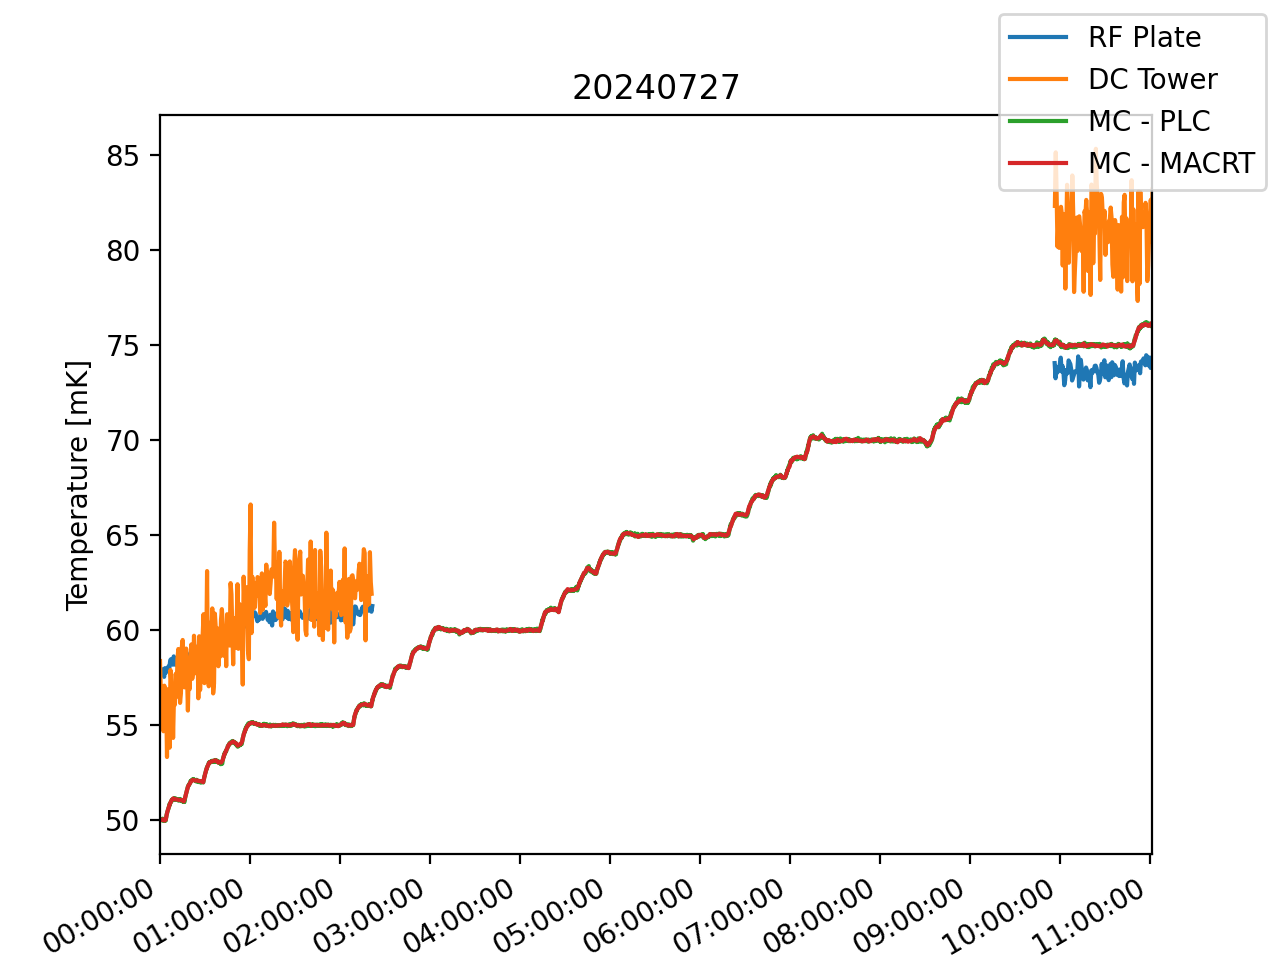

In [15]:
%matplotlib notebook
fig = plt.figure()
fig.gca().set_title(date)
plotChannel(df, 4,fig_obj=fig,label="RF Plate")
plotChannel(df, 5,fig_obj=fig,label="DC Tower")

fig.gca().plot(np.array(data_plc['datetime']), np.array(data_plc['FR MC'])*1e3, label='MC - PLC')

fig.gca().plot(res_mc['datetime'], res_mc['MIXING CHAMB_Conv']*1e3, label='MC - MACRT')

fig.gca().set_xlim([datetime.datetime(int(date[0:4]),int(date[4:6]),int(date[6:8]),0,0,0) , 
                    datetime.datetime.now() ])
fig.legend()